# S&P 500 Stock Behaviour and Risk Analysis

### Objective: 
We cannot predict all stocks equally, this projects atests to this by grouping six popular  stocks chosen from different sectors- Apple, NVIDIA, JPMorgan, ExxonMobil, Amazon and Lockheed Martin. we analyse their behaviour (volatility, risk and movements) rather than sector and use this insights to decide how confident we are in its forecast and what it would mean to hold them together in a portfolio.

### S&P 500 Companies:
Apple (AAPL)          : Consumer technology

NVIDIA (NVIDA)        : Semiconductors

JPMorgan (JPM)        : Finance

ExxonMobil (XOM)      : Energy

Amazon  (AMZN)        : e-commerce

Lockheed Martin (LMT) : Defence

### Approach:
1. Exploratory Data Analysis : trends, returns and volatility
2. Anomaly detection : flagging unusual shocks before modelling
3. Correlation Analysis : testing if linked stocks actually have same patterns
4. Clustering : grouping by volatility
5. Forecasting : model choice and confidence derived from the cluster
6. Apriori (Association Rule Mining) : exploratory pass asssesing movements in the stock


In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ['AAPL', 'NVDA','JPM', 'XOM', 'AMZN', 'LMT']
df = yf.download(tickers, start='2020-01-01', end='2026-06-17', threads=False)
close = df['Close'] 
close.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,JPM,LMT,NVDA,XOM
Date,,,,,,
2020-01-02,72.333855,94.900497,118.430321,335.413452,5.963803,52.947041
2020-01-03,71.630623,93.748497,116.867493,347.482178,5.868347,52.521358
2020-01-06,72.201439,95.143997,116.774544,346.953033,5.892957,52.924641
2020-01-07,71.861862,95.343002,114.789299,348.120422,5.964301,52.491486
2020-01-08,73.017830,94.598503,115.684769,345.206146,5.975488,51.699917


### 1. EDA

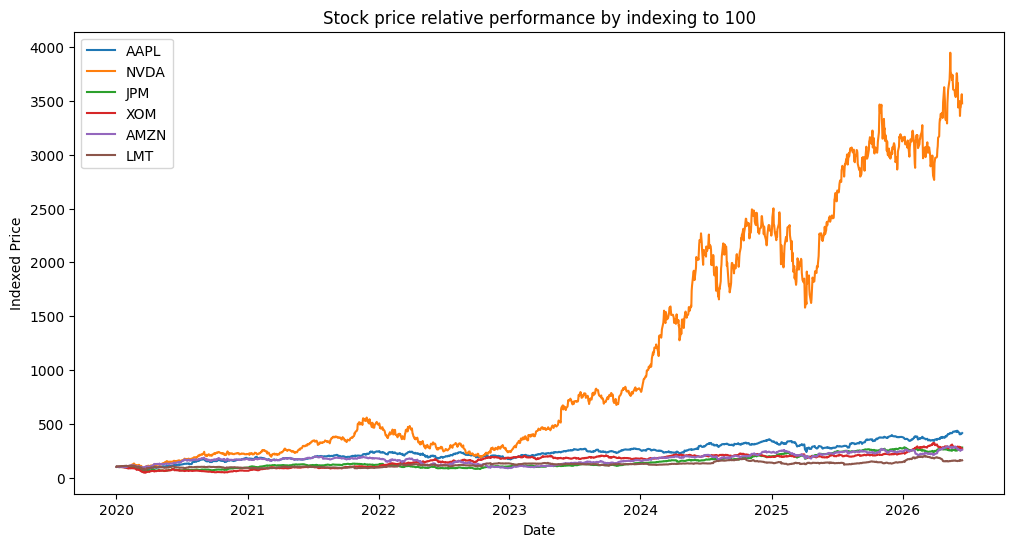

In [ ]:
# Indexing the prices to compare aginst each other since raw prices aren't comparable as is
norm = close/ close.iloc[0] * 100 #dividing each stock's price by its price on the first day and multiplying by 100 to set the starting point to 100 for all stocks, allowing for a relative performance comparison over time
plt.figure(figsize=(12,6))
for tick in tickers:
    plt.plot(norm.index, norm[tick], label = tick)
plt.title("Stock price relative performance by indexing to 100")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.legend()
plt.show()
    

In [13]:
# Calculating the returns (preping for correlation and anomaly detection)
returns = close.pct_change().dropna() #calculating change in consecutive prices and dropping the first row since it doesnt have anything to comapre it with
returns.head()

Ticker,AAPL,AMZN,JPM,LMT,NVDA,XOM
Date,,,,,,
2020-01-03,-0.009722,-0.012139,-0.013196,0.035982,-0.016006,-0.008040
2020-01-06,0.007969,0.014886,-0.000795,-0.001523,0.004194,0.007678
2020-01-07,-0.004703,0.002092,-0.017001,0.003365,0.012107,-0.008184
2020-01-08,0.016086,-0.007809,0.007801,-0.008371,0.001876,-0.015080
2020-01-09,0.021241,0.004799,0.003651,0.009488,0.010983,0.007655


Ticker
NVDA    0.522814
AMZN    0.353587
XOM     0.326409
AAPL    0.313435
JPM     0.309446
LMT     0.263550
dtype: float64


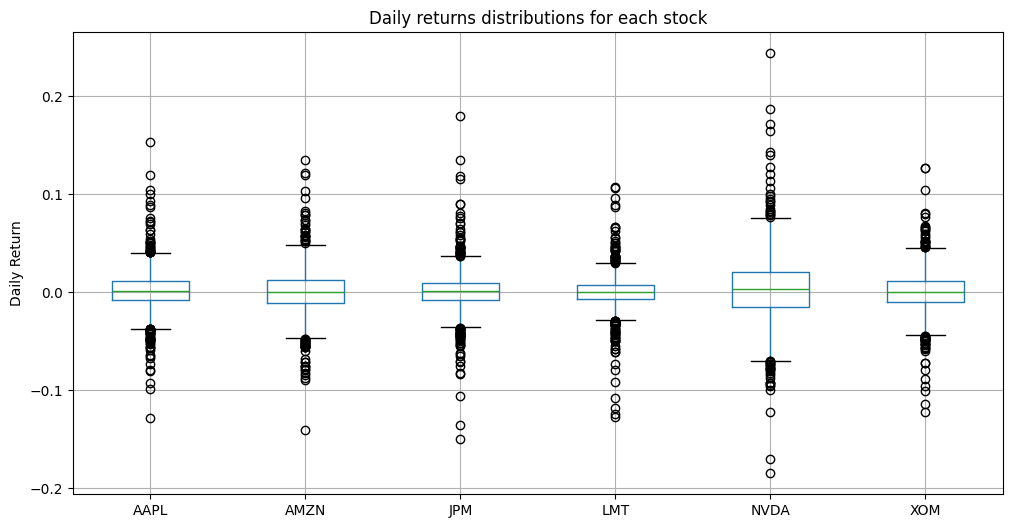

In [ ]:
# Calculating distribution and volatility ranking
annual_vol = returns.std() * np.sqrt(252) #annualizing the volatility by multiplying the standard deviation of returns by the square root of 252 (the number of trading days in a year)
print(annual_vol.sort_values(ascending = False)) #the stocks in descending volatility

plt.figure(figsize=(12,6))
returns.boxplot()
plt.title("Daily returns distributions for each stock")
plt.ylabel("Daily Return")
plt.show()

####  
We can observe after normalization, NVIDIA relative prices have the highest swings and even in terms of growth, however an observed dip in 2023 is obeserved, which we will analyse through anomaly detection.
When returns were calculated, and plotted using boxplots, the daily returns for NVIDIA showed dispersion from the mean while Lockheed Martin followed by JPMorgan had the least dispersion.
The annualized volatility confirms this by observing that NVIDIA has a 52% volatility compared to Lockheed Martin which is at 26%, almost double that of NVIDIA. 
Lockheed Martin is a defensive stock figuratevely and literally. Characterised by its long term government contracts thus, less sensitive to economic cycles.
We can observe cluster formation already from this: NVDA as highly volatile, AMZN as next most volatile, XOM, AAPL, JPM as moderately volatile and LMT as last volatile

### 2. Anomaly Detection

In [15]:
# Anomaly detection using Z-scores
from scipy import stats
z_scores = returns.apply(stats.zscore) #how many standard deviations each return is from the mean, which helps in detecting outliers
anomalies = z_scores.abs() > 3 #identifying returns that are more than 3 standard deviations away from the mean as anomalies
print(anomalies.sum()) #anomaly count per stock

Ticker
AAPL    23
AMZN    26
JPM     25
LMT     27
NVDA    14
XOM     19
dtype: int64


###
An interesting observation on the anomaly detection, we expected NVDA to have the highest anomalies however, LMT has has almost double. This is because Z-sore are done against the stocks own mean and standard deviation (relative anomalies). NVDA is continually having high swings and hence has a big standard deviation. However for LMT, the standard deviation is small therefore, a small move easily blows past the 3 standard deviations from its baseline. Hence forms a basis on risk in this analysis. We proceed to assess the relative anomalies.

In [21]:
abs_threshold = 0.05 #identifying returns that are greater than 5% in absolute value as anomalies, which can capture significant price movements that may not be flagged by Z-scores alone
jump = returns.abs() > abs_threshold
print(jump.sum())

Ticker
AAPL     35
AMZN     57
JPM      36
LMT      25
NVDA    176
XOM      38
dtype: int64


### Anomaly detection : relative vs. absolute
We observe the relative anomalies is what we expected earlier, NVDA having almost triple that of the next stock. We observe LMT and AMZN are comparatively calmer to the rest as they have the lowest anomalies.
 

In [27]:
comparison = pd.DataFrame({'Relative anomalies':anomalies.sum(), 'Absolute anomalies': jump.sum()})
print(comparison)

        Relative anomalies  Absolute anomalies
Ticker                                        
AAPL                    23                  35
AMZN                    26                  57
JPM                     25                  36
LMT                     27                  25
NVDA                    14                 176
XOM                     19                  38


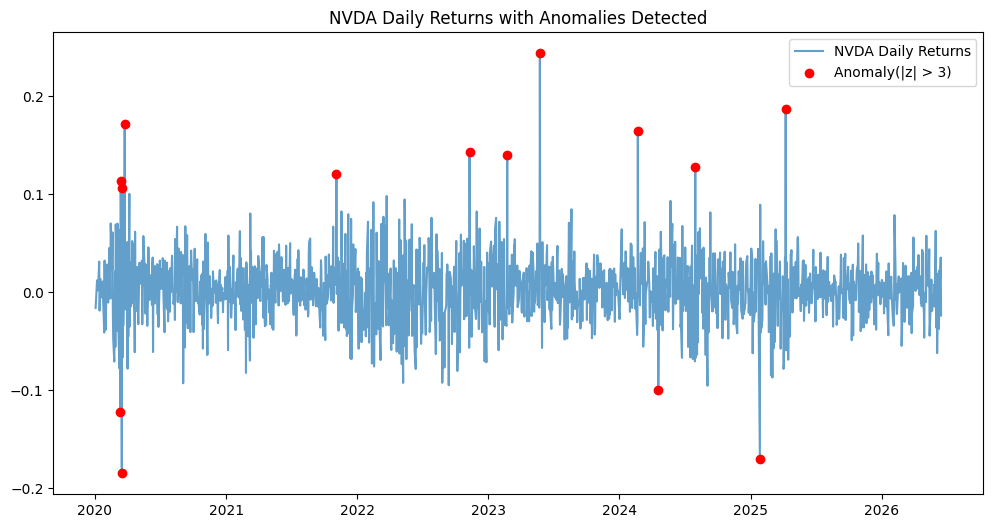

In [20]:
# Days with the anomlies which can identify if  there were events that caused them.
plt.figure(figsize=(12,6))
plt.plot(returns.index, returns['NVDA'], label = 'NVDA Daily Returns', alpha = 0.7)
plt.scatter(returns.index[anomalies['NVDA']], returns['NVDA'][anomalies['NVDA']], color = 'red', label = 'Anomaly(|z| > 3)', zorder = 5 )
plt.title("NVDA Daily Returns with Anomalies Detected")
plt.legend()
plt.show()